In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import os
os.getcwd()

'C:\\Users\\gk413'

In [13]:
import pandas as pd

df = pd.read_csv(r"C:\Users\gk413\Downloads\healthcare_dataset.csv")

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,09-10-2022,Penicillin,Abnormal


In [15]:
df.shape

(55500, 15)

In [21]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"], 
    dayfirst=True
)

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"], 
    dayfirst=True
)

In [23]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    format="%d-%m-%Y"
)

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"],
    format="%d-%m-%Y"
)

In [25]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    dayfirst=True,
    errors="coerce"
)

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"],
    dayfirst=True,
    errors="coerce"
)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [29]:
df["Length of Stay"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

In [31]:
df[["Date of Admission", "Discharge Date", "Length of Stay"]].head()

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [33]:
total_patients = df.shape[0]
print("Total Patients:", total_patients)

Total Patients: 55500


In [35]:
total_billing = df["Billing Amount"].sum()
print("Total Billing:", total_billing)

Total Billing: 1417432043.395237


In [37]:
avg_billing = df["Billing Amount"].mean()
print("Average Billing:", avg_billing)

Average Billing: 25539.31609721148


In [39]:
avg_stay = df["Length of Stay"].mean()
print("Average Length of Stay:", avg_stay)

Average Length of Stay: 15.50900900900901


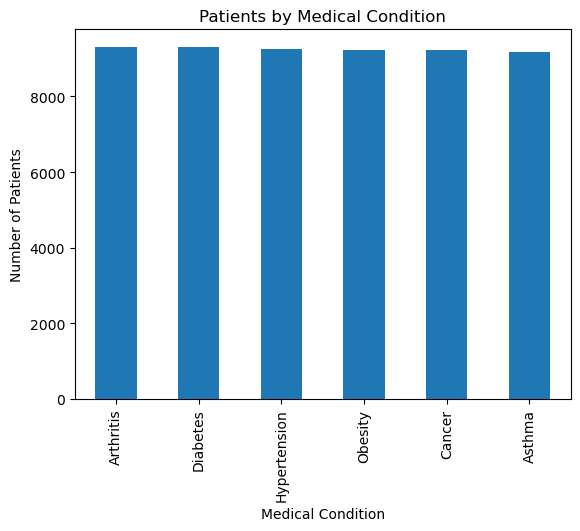

In [41]:
import matplotlib.pyplot as plt

df["Medical Condition"].value_counts().plot(kind="bar")

plt.title("Patients by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")

plt.show()

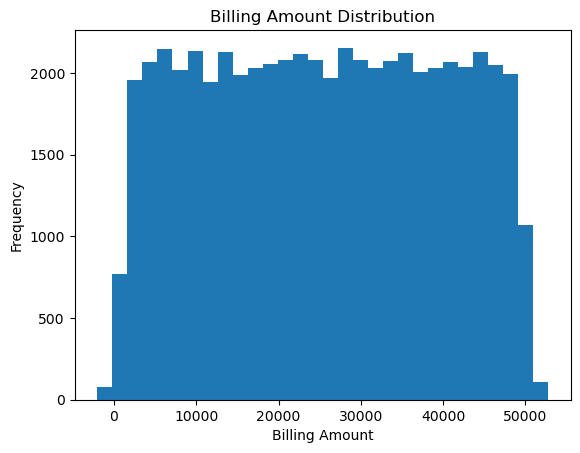

In [43]:
df["Billing Amount"].plot(kind="hist", bins=30)

plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount")
plt.ylabel("Frequency")

plt.show()

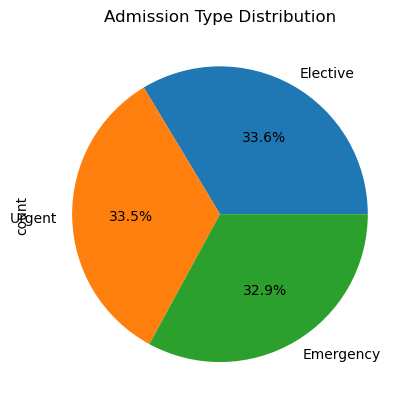

In [45]:
df["Admission Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Admission Type Distribution")

plt.show()

In [49]:
df.to_csv("cleaned_healthcare_dataset.csv", index=False)